/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/desipipe/abacus-2ndgen-altmtl/mesh2_spectrum_poles_LRG_z0.8-1.1_NGC_weight-default-FKP_reshuffle_0.h5


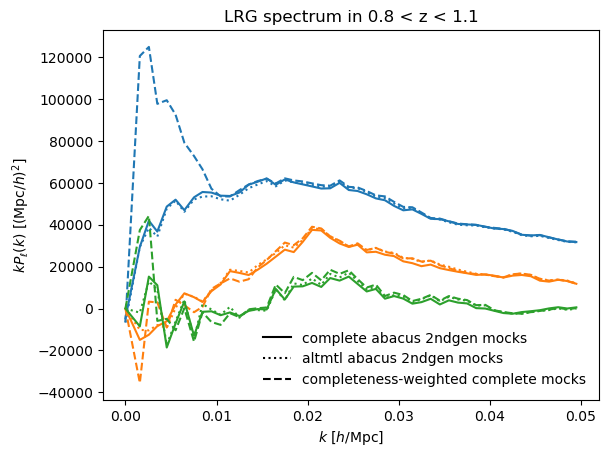

In [2]:
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt

import lsstypes as types
from clustering_statistics import tools, box_tools

stats_dir = Path('/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/desipipe')

kind = 'mesh2_spectrum'
nmocks = 2
region = 'NGC'
weight = 'default-FKP'

for tracer in ['LRG', 'ELG_LOP', 'QSO'][:1]:
    for zrange in tools.propose_fiducial('zranges', tracer)[-1:]:
        fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, version='abacus-2ndgen-complete', tracer=tracer,
                                  zrange=zrange, region=region, weight=weight, imock=imock) for imock in range(nmocks)]
        mean_complete = types.mean([types.read(fn) for fn in fns])
        
        fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, version='abacus-2ndgen-altmtl', tracer=tracer,
                                  zrange=zrange, region=region, weight=weight, imock=imock) for imock in range(nmocks)]
        mean_altmtl = types.mean([types.read(fn) for fn in fns])
        
        fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, version='abacus-2ndgen-altmtl', tracer=tracer,
                                  zrange=zrange, region=region, weight=weight, extra='reshuffle', imock=imock) for imock in range(nmocks)]
        print(fns[0])
        mean_altmtl_complete = types.mean([types.read(fn) for fn in fns])
        mean_complete = mean_complete.select(k=slice(0, None, 1)).select(k=(0., 0.05))
        mean_altmtl = mean_altmtl.match(mean_complete)
        mean_altmtl_complete = mean_altmtl_complete.match(mean_complete)
        
        fig, ax = plt.subplots()
        ax.set_title(f'{tracer} spectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
        kpow = 0
        for ill, ell in enumerate(mean_complete.ells):
            color = f'C{ill:d}'
            pole = mean_complete.get(ell)
            ax.plot(k:=pole.coords('k'), k**kpow * pole.value(), color=color, linestyle='-')
            pole = mean_altmtl.get(ell)
            ax.plot(k:=pole.coords('k'), k**kpow * pole.value(), color=color, linestyle=':')
            pole = mean_altmtl_complete.get(ell)
            ax.plot(k:=pole.coords('k'), k**kpow * pole.value(), color=color, linestyle='--')
        ax.plot([], [], color='k', linestyle='-', label='complete abacus 2ndgen mocks')
        ax.plot([], [], color='k', linestyle=':', label='altmtl abacus 2ndgen mocks')
        ax.plot([], [], color='k', linestyle='--', label='completeness-weighted complete mocks')
        ax.set_ylabel(rf'$k P_\ell(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
        ax.set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
        ax.legend(frameon=False, loc=4)
        plt.show()